In [17]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

import csv

%cd ..
from scripts import *

/Users/sergejpelko/Desktop/Rudolfovo/coloring_max_stable_set


In [50]:
INSTANCES = {
    "hamming6_2": "instances/stable_set/hamming6_2_stable_set_edge_list.txt",
    "hamming6_4": "instances/stable_set/hamming6_4_stable_set_edge_list.txt",
    "paley61":    "instances/stable_set/paley61_stable_set_edge_list.txt",
    "dsjc125.9":  "instances/stable_set/dsjc125.9_stable_set_edge_list.txt",
    "keller4":    "instances/stable_set/keller4_stable_set_edge_list.txt",
    "MANN_9":     "instances/stable_set/MANN_a9_stable_set_edge_list.txt",
    "C125.9":     "instances/stable_set/C125.9_stable_set_edge_list.txt",
    "evil_myc5x24": "instances/stable_set/evil-N120-p98-myc5x24_stable_set_edge_list.txt",
}

TRUE_VALUES = {
    "hamming6_2": 32,
    "hamming6_4": 4,
    "paley61": 5,
    "dsjc125.9": 34,
    "keller4": 11,
    "MANN_9": 16,
    "C125.9": 34,
    "evil_myc5x24": 48,
}
A = 1.0
B_RATIOS = [1.5, 2, 3, 5, 10, 20]
BASES = [3, 4, 5, 10, 15, 20]
NUM_ATTEMPTS = 100
MAX_ITERS = 3000
SEED = 0

In [137]:
param_sweep_path = "../results/param_sweep_results.csv"

with open(param_sweep_path, 'r') as f:
    reader = csv.DictReader(f)
    data = list(reader)
data[0]

{'instance': 'hamming6_2',
 'n': '64',
 'm': '192',
 'A': '1.0',
 'B': '1.5',
 'ratio': '1.5',
 'base': '3',
 'best': '23',
 'mean': '18.84',
 'std': '2.1758676430334636',
 'sizes': '[22, 18, 16, 17, 17, 18, 15, 19, 19, 23, 18, 16, 20, 19, 18, 20, 23, 23, 22, 21, 18, 18, 17, 18, 18, 21, 19, 15, 15, 23, 16, 19, 17, 18, 19, 17, 19, 17, 21, 18, 22, 18, 20, 22, 19, 17, 20, 21, 17, 19]'}

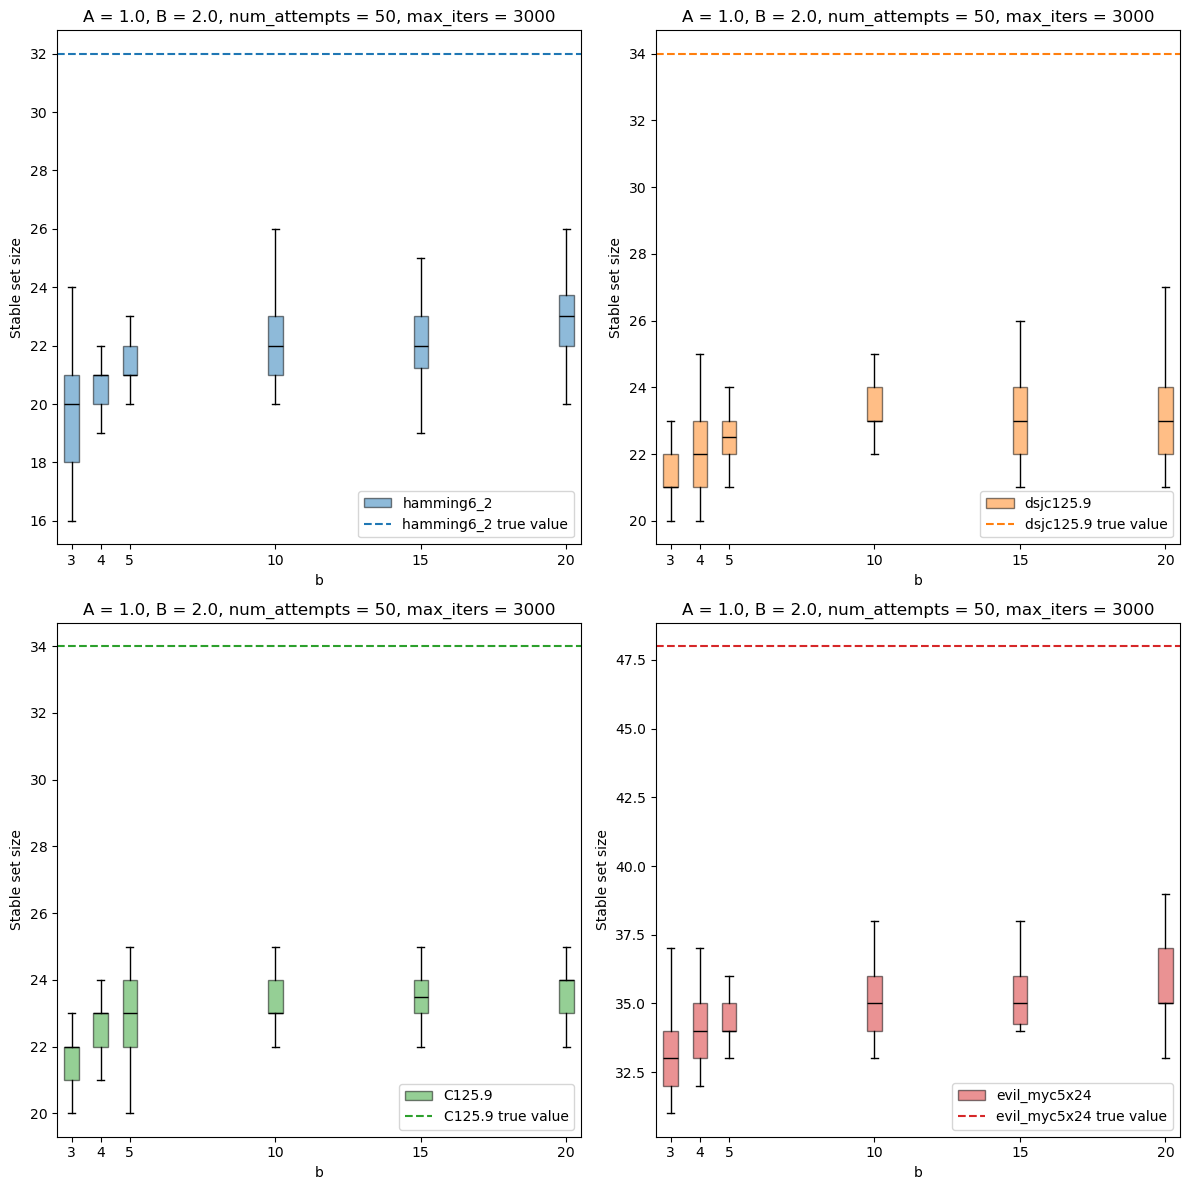

In [170]:

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

ratio = "2"
fig, ax = plt.subplots(2, 2, figsize=(12, 12))
for i, (instance, size) in enumerate(INSTANCES.items()):
    data_per_instance = [e for e in data if e["instance"] == instance]
    data_per_base = [e for e in data_per_instance if e["ratio"] == ratio]
    bases = np.array([int(e["base"]) for e in data_per_base])
    sizes = np.array([e["sizes"] for e in data_per_base])
    sizes = [list(map(int, s.strip("[]").split(","))) for s in sizes]
    # plt.boxplot(sizes, positions=bases, widths=0.5, patch_artist=True, boxprops=dict(facecolor=colors[i], alpha=0.5), medianprops=dict(color="black"), showfliers=False, label=f"{instance}")
    # plt.axhline(y=TRUE_VALUES[instance], color=colors[i], linestyle="--", label=f"{instance} true value")
    ax[i//2, i%2].boxplot(sizes, positions=bases, widths=0.5, patch_artist=True, boxprops=dict(facecolor=colors[i], alpha=0.5), medianprops=dict(color="black"), showfliers=False, label=f"{instance}")
    ax[i//2, i%2].axhline(y=TRUE_VALUES[instance], color=colors[i], linestyle="--", label=f"{instance} true value")

    # ax[i//2, i%2].set_ylim(0, TRUE_VALUES[instance] + 1)
    ax[i//2, i%2].legend()
    ax[i//2, i%2].set_xlabel("b")
    ax[i//2, i%2].set_ylabel("Stable set size")
    ax[i//2, i%2].set_title(f"A = {A}, B = {float(ratio) * A}, num_attempts = {NUM_ATTEMPTS}, max_iters = {MAX_ITERS}")

plt.tight_layout()
plt.savefig(f"../results/param_sweep_results_A{A}_B{float(ratio) * A}_num_attempts{NUM_ATTEMPTS}_max_iters{MAX_ITERS}.png")
plt.show()

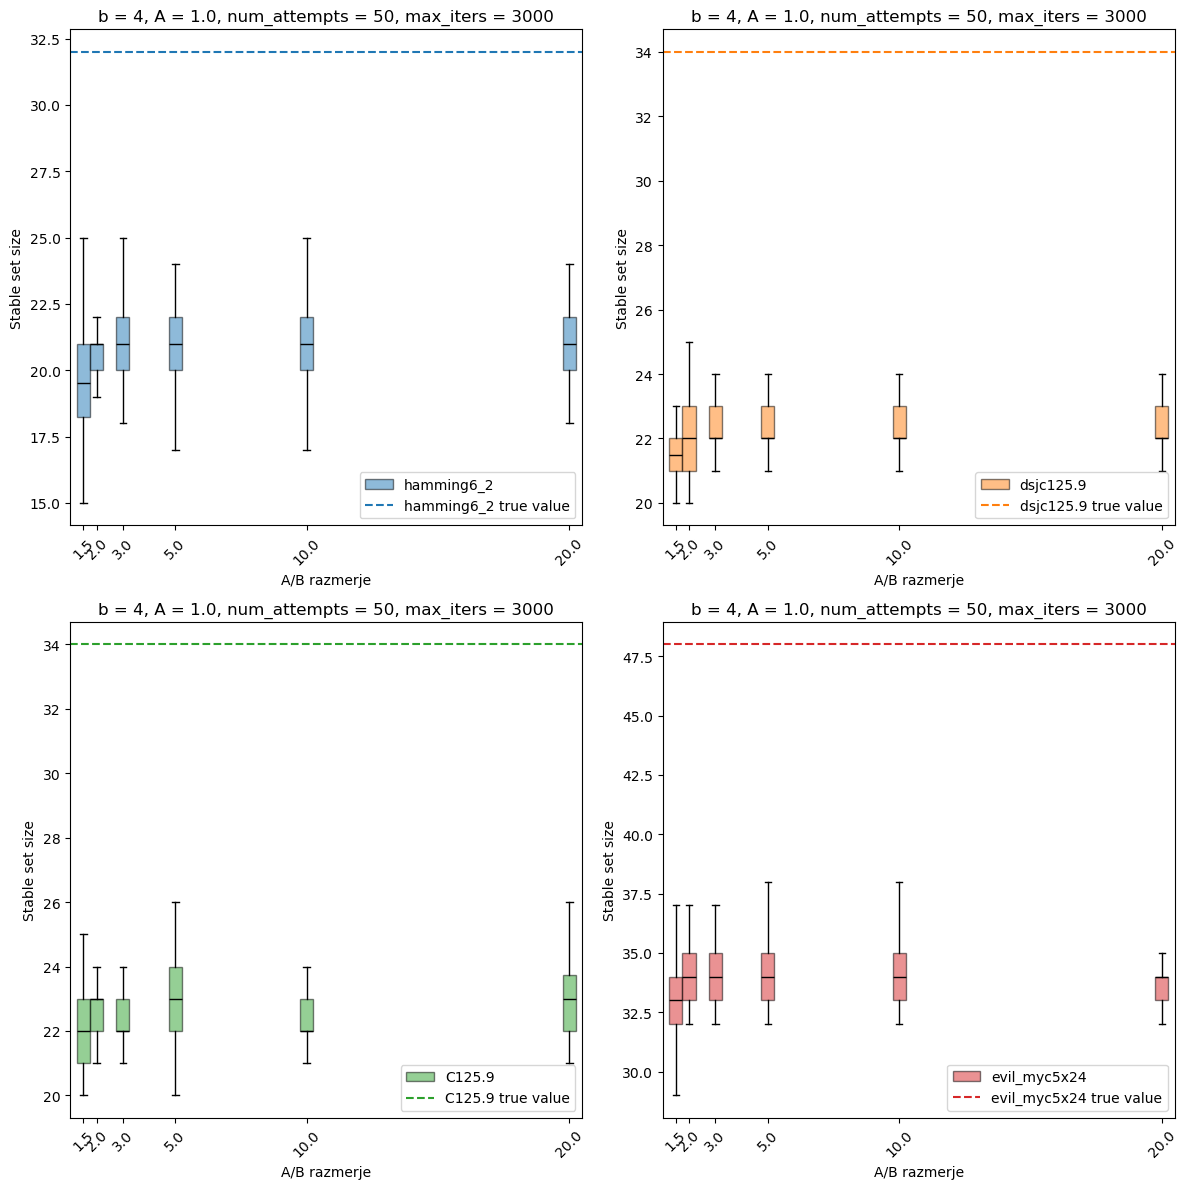

In [173]:

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

base = "4"
fig, ax = plt.subplots(2,2, figsize=(12,12))

for i, (instance, size) in enumerate(INSTANCES.items()):
    data_per_instance = [e for e in data if e["instance"] == instance]
    data_per_base = [e for e in data_per_instance if e["base"] == base]
    ratios = np.array([float(e["ratio"]) for e in data_per_base])
    sizes = np.array([e["sizes"] for e in data_per_base])
    sizes = [list(map(int, s.strip("[]").split(","))) for s in sizes]
    ax[i//2, i%2].boxplot(sizes, positions=ratios, widths=0.5, patch_artist=True, boxprops=dict(facecolor=colors[i], alpha=0.5), medianprops=dict(color="black"), showfliers=False, label=f"{instance}")
    ax[i//2, i%2].axhline(y=TRUE_VALUES[instance], color=colors[i], linestyle="--", label=f"{instance} true value")
    ax[i//2, i%2].set_xlabel("A/B ratio")
    ax[i//2, i%2].set_ylabel("Stable set size")
    ax[i//2, i%2].set_title(f"{instance}")
    # ax[i//2, i%2].set_ylim(0, TRUE_VALUES[instance] + 1)
    ax[i//2, i%2].legend()
    ax[i//2, i%2].set_xlabel("A/B razmerje")
    ax[i//2, i%2].set_ylabel("Stable set size")
    ax[i//2, i%2].tick_params(axis='x', labelrotation=45)
    ax[i//2, i%2].set_title(f"b = {base}, A = {A}, num_attempts = {NUM_ATTEMPTS}, max_iters = {MAX_ITERS}")


plt.tight_layout()
plt.savefig(f"../results/param_sweep_results_base{base}_A{A}_num_attempts{NUM_ATTEMPTS}_max_iters{MAX_ITERS}.png")
plt.show()


In [5]:
benchmark_stable_set_path = "../results/benchmark_stable_set_results.csv"
benchmark_results = pd.read_csv(benchmark_stable_set_path)

benchmark_results = benchmark_results.drop(columns=["A", "B", "base", "std"])
benchmark_results["error"] = benchmark_results["gap"] / benchmark_results["known_best"]
with open("../report/table.tex", "w") as f:
    f.write(benchmark_results.to_latex(index=False, float_format="%.2f", escape=True))

Target value 4 reached at iteration 93, terminating early.
Target value 4 reached at iteration 250, terminating early.
Target value 4 reached at iteration 33, terminating early.
Target value 4 reached at iteration 277, terminating early.
Target value 4 reached at iteration 100, terminating early.
Target value 4 reached at iteration 38, terminating early.
Target value 4 reached at iteration 279, terminating early.
Target value 4 reached at iteration 174, terminating early.
Target value 4 reached at iteration 204, terminating early.
Target value 4 reached at iteration 289, terminating early.
Target value 5 reached at iteration 197, terminating early.
Target value 5 reached at iteration 152, terminating early.
Target value 5 reached at iteration 234, terminating early.
Target value 5 reached at iteration 144, terminating early.
Target value 5 reached at iteration 15, terminating early.
Target value 5 reached at iteration 43, terminating early.
Target value 5 reached at iteration 61, termi

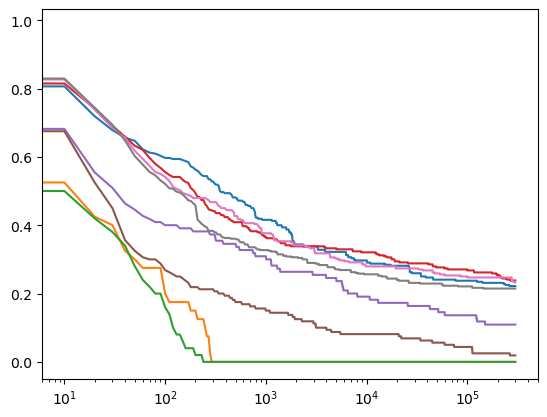

In [55]:
n_repeats = 10
max_iters = 300000
record_every = 10

for name, instance in INSTANCES.items():
    graph = CSRGraph.from_edge_list_file(INSTANCES[name])
    histories = np.ones((n_repeats, max_iters // record_every)) * TRUE_VALUES[name]
    for n in range(n_repeats):
        problem = MaxStableSetProblem(graph, A=1.0, B=2.0)

        state, history = petford_welsh(
            problem,
            b=4,
            max_iters=max_iters,
            rng=np.random.default_rng(),
            record_every=record_every,
            target=TRUE_VALUES[name]
        )
        histories[n, :len(history)] = np.sum(history, axis=1)

    best_values = np.mean(histories, axis=0)
    gap = (TRUE_VALUES[name] - best_values) / TRUE_VALUES[name]
    t = np.arange(0, max_iters, record_every)

    plt.semilogx(t[:len(gap)], gap)

plt.show()